In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

## Config

특정 `(step, block)` 위치의 MLP 기여분(`delta_mlp = L_output − L_after_attn`)을 0으로 만들어
**baseline 이미지 vs MLP-skip 이미지**를 비교한다.

- `SKIP_TARGETS`: `{(step_idx, block_idx), ...}` 에 있는 블록은 MLP residual을 건너뛴다.
- `SKIP_BRANCH`: `"both"` / `"cond"` / `"uncond"` — CFG 배치 중 어느 쪽에 적용할지.

블록 내부 흐름:
```
  hidden = L_minus_1
  hidden = hidden + gate * attn(norm1(hidden))     → L_after_attn
  hidden = hidden + gate * ff(norm2(hidden))        → L_output
```
skip 시에는 `L_output`의 image stream을 `L_after_attn`으로 덮어써 MLP 기여분을 제거.

In [2]:
from pathlib import Path

DEVICE         = "cuda"
MODEL_ID       = "stabilityai/stable-diffusion-3-medium-diffusers"
NUM_STEPS      = 28
GUIDANCE_SCALE = 7.0
N_BLOCKS       = 24

PROMPT = "cat"
SEED   = 0

# ── 실험 대상 ─────────────────────────────────────────────
# (step, block) 튜플 set. 여러 개 넣으면 동시에 skip.
SKIP_TARGETS = {(0, 17)}
SKIP_BRANCH  = "both"   # "both" | "cond" | "uncond"

OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"prompt : {PROMPT!r}  seed={SEED}")
print(f"skip   : {sorted(SKIP_TARGETS)}  branch={SKIP_BRANCH}")

prompt : 'cat'  seed=0
skip   : [(0, 17)]  branch=both


## Load Pipeline

In [3]:
import torch
from diffusers import StableDiffusion3Pipeline

pipe = StableDiffusion3Pipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
).to(DEVICE)
pipe.set_progress_bar_config(disable=True)

/home/haeun/miniconda3/envs/C3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 9/9 [00:03<00:00,  2.71it/s]


## MLP-skip Hook

`decomposed_capture.ipynb` / `sd3_hook.py` 와 동일한 패치 패턴.

- `norm2.register_forward_pre_hook` 로 `L_after_attn` 캡처
- 원본 forward 실행 → `L_output` 확보
- `(step, block) ∈ SKIP_TARGETS` 이면 해당 branch 의 image stream 을 `L_after_attn` 으로 교체해서 반환

In [4]:
from functools import wraps

# ── global control state ─────────────────────────────────
# targets : {(step, block): mode}  where mode ∈ {"mlp", "attn", "l-1"}
#   - mlp  : img ← L_after_attn           (delta_mlp  = 0)
#   - attn : img ← L_output - (L_after_attn - L_minus_1)  (delta_attn = 0)
#   - l-1  : img ← L_minus_1              (delta_attn = delta_mlp = 0)
denoising_step = [0]
_skip_cfg = {
    "targets": {},       # {(step, block): mode}
    "branch":  "both",
    "on":      False,
}

def _branch_slice(branch, batch_size):
    """CFG batch = [uncond, cond]. 선택 branch index list 반환."""
    if batch_size == 1:
        return [0]
    if branch == "uncond": return [0]
    if branch == "cond":   return [1]
    return [0, 1]   # both

# ── transformer.forward 래핑으로 step 추적 ────────────────
if not getattr(pipe.transformer.forward, "_is_step_tracked", False):
    _orig_transformer_forward = pipe.transformer.forward

    @wraps(_orig_transformer_forward)
    def _step_tracked_forward(*args, **kwargs):
        result = _orig_transformer_forward(*args, **kwargs)
        denoising_step[0] += 1
        return result

    _step_tracked_forward._is_step_tracked = True
    pipe.transformer.forward = _step_tracked_forward
    print("step tracker attached.")
else:
    print("step tracker already attached.")

# ── 각 JointTransformerBlock 패치 ─────────────────────────
already = 0
for block_idx, block in enumerate(pipe.transformer.transformer_blocks):
    if getattr(block.forward, "_is_mlp_skip_patched", False):
        already += 1
        continue

    original_forward = block.forward

    def _make_patched(orig_fwd, idx, blk):
        @wraps(orig_fwd)
        def patched_forward(hidden_states, encoder_hidden_states, temb, *args, **kwargs):
            if not _skip_cfg["on"]:
                return orig_fwd(hidden_states, encoder_hidden_states, temb, *args, **kwargs)

            s = denoising_step[0]
            mode = _skip_cfg["targets"].get((s, idx))

            if mode is None:
                return orig_fwd(hidden_states, encoder_hidden_states, temb, *args, **kwargs)

            # L_minus_1 (block 입력, image stream)
            L_minus_1 = hidden_states.detach()

            # L_after_attn 캡처 (norm2 직전)
            buf = {}
            def _capture(module, args_in):
                if "L" not in buf and args_in:
                    buf["L"] = args_in[0].detach()
            handle = blk.norm2.register_forward_pre_hook(_capture)
            try:
                block_output = orig_fwd(hidden_states, encoder_hidden_states, temb, *args, **kwargs)
            finally:
                handle.remove()

            if "L" not in buf:
                return block_output

            L_after_attn = buf["L"]                           # (B, T_img, D)

            is_tuple = isinstance(block_output, tuple)
            img_out  = block_output[1] if is_tuple else block_output   # L_output
            img_new  = img_out.clone()

            # 모드별 replacement 계산 (residual-level surgery)
            if mode == "mlp":
                repl = L_after_attn
            elif mode == "attn":
                repl = img_out - L_after_attn + L_minus_1
            elif mode == "l-1":
                repl = L_minus_1
            else:
                return block_output

            # 지정 branch 만 교체
            for bi in _branch_slice(_skip_cfg["branch"], img_out.shape[0]):
                img_new[bi] = repl[bi].to(img_out.dtype)

            if is_tuple:
                return (block_output[0], img_new)
            return img_new

        patched_forward._is_mlp_skip_patched = True
        return patched_forward

    block.forward = _make_patched(original_forward, block_idx, block)

if already:
    print(f"⚠ {already} blocks already patched — restart kernel to re-patch")
else:
    print(f"{len(pipe.transformer.transformer_blocks)} blocks patched.")
print("hook ready.")

step tracker attached.
24 blocks patched.
hook ready.


## Run helper

In [5]:
import gc

def run(prompt, seed, skip_targets=None, branch="both", mode="mlp"):
    """
    skip_targets:
      - None                         → baseline
      - set of (step, block)         → 모두 `mode` 로 적용 (기본 "mlp")
      - dict {(step, block): mode_i} → per-target 모드 지정
    mode ∈ {"mlp", "attn", "l-1"}.
    """
    if skip_targets is None:
        targets = {}
    elif isinstance(skip_targets, dict):
        targets = dict(skip_targets)
    else:
        targets = {t: mode for t in skip_targets}

    _skip_cfg["targets"] = targets
    _skip_cfg["branch"]  = branch
    _skip_cfg["on"]      = bool(targets)
    denoising_step[0]    = 0

    generator = torch.Generator(device=pipe.device).manual_seed(seed)
    image = pipe(
        prompt,
        num_inference_steps=NUM_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        generator=generator,
    ).images[0]

    _skip_cfg["on"] = False
    torch.cuda.empty_cache(); gc.collect()
    return image

## Generate: baseline vs MLP-skip

In [6]:
from PIL import Image

MODES = ["mlp", "attn", "l-1"]

print("▶ baseline ...")
img_base = run(PROMPT, SEED, skip_targets=None)

imgs = {}
for m in MODES:
    print(f"▶ skip {sorted(SKIP_TARGETS)} mode={m} branch={SKIP_BRANCH} ...")
    imgs[m] = run(PROMPT, SEED, skip_targets=SKIP_TARGETS, branch=SKIP_BRANCH, mode=m)

tag = "_".join(f"s{s}b{b}" for s, b in sorted(SKIP_TARGETS))

# 가로 스트립: [baseline | mlp | attn | l-1]
panels = [("baseline", img_base)] + [(m, imgs[m]) for m in MODES]
w, h = img_base.size
combined = Image.new("RGB", (w * len(panels), h))
for i, (_, im) in enumerate(panels):
    combined.paste(im, (i * w, 0))
combined.save(OUTPUT_DIR / f"compare_{tag}_{SKIP_BRANCH}_seed{SEED}_allmodes.png")
print("saved to", OUTPUT_DIR)

▶ baseline ...
▶ skip [(0, 17)] mode=mlp branch=both ...
▶ skip [(0, 17)] mode=attn branch=both ...
▶ skip [(0, 17)] mode=l-1 branch=both ...
saved to output


## Side-by-side

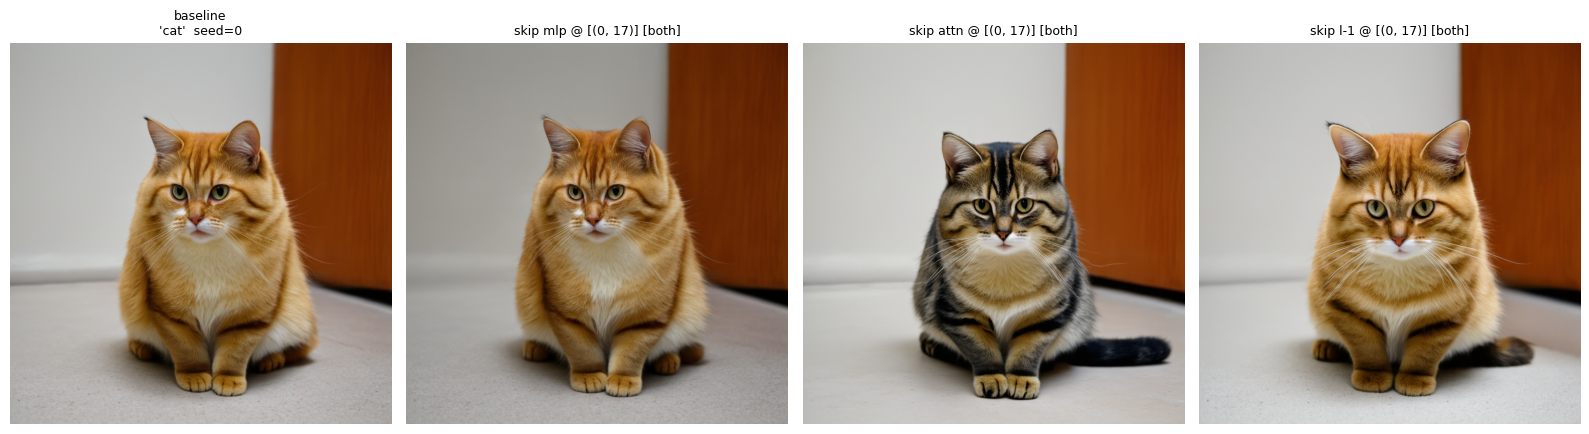

In [7]:
import matplotlib.pyplot as plt

panels = [("baseline", img_base)] + [(m, imgs[m]) for m in MODES]
fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4.4))
for ax, (name, im) in zip(axes, panels):
    ax.imshow(im)
    if name == "baseline":
        ax.set_title(f"baseline\n{PROMPT!r}  seed={SEED}", fontsize=9)
    else:
        ax.set_title(f"skip {name} @ {sorted(SKIP_TARGETS)} [{SKIP_BRANCH}]", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"compare_{tag}_{SKIP_BRANCH}_seed{SEED}_allmodes.png", dpi=130)
plt.show()

## (선택) Sweep: 블록별 MLP skip 영향

특정 step 에서 block 을 하나씩 바꿔가며 skip → grid 저장.

In [ ]:
PROMPTS = [
    "airplane",
    "bird",
    "car",
    "clock",
    "couch",
    "elephant",
    "train",
    "umbrella",
]

SWEEP_BLOCKS = list(range(N_BLOCKS))   # group C: all 24 blocks
SWEEP_STEPS  = list(range(NUM_STEPS))
SWEEP_MODES  = ["mlp", "attn", "l-1"]

def run_prompt_sweep(prompt, blocks):
    print(f"\n=== prompt: {prompt!r} ===")
    print("▶ baseline ...")
    base_img = run(prompt, SEED, skip_targets=None)

    # (b, mode) → image
    results = {}
    for b in blocks:
        for m in SWEEP_MODES:
            print(f"  block={b:>2d} mode={m:<5s} steps={len(SWEEP_STEPS)} ...")
            targets = {(s, b): m for s in SWEEP_STEPS}
            results[(b, m)] = run(prompt, SEED, skip_targets=targets, branch=SKIP_BRANCH)

    cols = len(SWEEP_MODES)
    rows = 1 + len(blocks)          # row 0 = baseline + mode header
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.8, rows*2.9))
    if rows == 1: axes = axes[None, :]
    if cols == 1: axes = axes[:, None]

    # row 0: baseline (col 0) + mode headers
    for c, m in enumerate(SWEEP_MODES):
        ax = axes[0, c]
        if c == 0:
            ax.imshow(base_img); ax.set_title(f"baseline\nmode→ {m}", fontsize=9)
        else:
            ax.set_title(f"mode→ {m}", fontsize=10)
        ax.axis("off")

    # row 1..N: block × mode
    for r, b in enumerate(blocks, start=1):
        for c, m in enumerate(SWEEP_MODES):
            ax = axes[r, c]
            ax.imshow(results[(b, m)])
            ax.set_title(f"b{b} · {m}", fontsize=9)
            ax.axis("off")

    step_tag = f"step{SWEEP_STEPS[0]}" if len(SWEEP_STEPS) == 1 else f"{len(SWEEP_STEPS)}steps"
    safe_prompt = prompt.replace(" ", "_")
    fig.suptitle(
        f'"{prompt}"  seed={SEED}  —  ablation sweep ({step_tag}, all {len(blocks)} blocks)',
        fontsize=11,
    )
    plt.tight_layout()
    out = OUTPUT_DIR / f"sweep_modes_{step_tag}_{SKIP_BRANCH}_seed{SEED}_{safe_prompt}.png"
    plt.savefig(out, dpi=130)
    plt.show()
    print(f"  saved → {out}")

for p in PROMPTS:
    run_prompt_sweep(p, SWEEP_BLOCKS)

In [ ]:
## 이미 저장된 sweep PNG 만 가져와 가로로 합쳐 최종 이미지 하나 저장
## (파이프라인/스윕 재실행 불필요 — 디스크의 PNG 만 사용)

from pathlib import Path
from PIL import Image

OUT_DIR = Path("./output")
PROMPTS = ["airplane", "bird", "car", "clock",
           "couch", "elephant", "train", "umbrella"]
PATTERN = "sweep_modes_28steps_both_seed0_{p}.png"

paths = [OUT_DIR / PATTERN.format(p=p) for p in PROMPTS]
missing = [p for p in paths if not p.exists()]
assert not missing, f"missing: {missing}"

tiles = [Image.open(p).convert("RGB") for p in paths]
H = max(t.height for t in tiles)
W = sum(t.width for t in tiles)

merged = Image.new("RGB", (W, H), (255, 255, 255))
x = 0
for t in tiles:
    merged.paste(t, (x, 0))
    x += t.width

out = OUT_DIR / "sweep_modes_28steps_both_seed0_ALL.png"
merged.save(out)
print(f"saved → {out}  size={merged.size}")